In [1]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────────
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')

2026-04-24 17:07:13,185 | INFO | Train: (74680, 19) | Test: (18670, 19)
2026-04-24 17:07:13,187 | INFO | Train — will_return=1 (minority): 2,241 (0.030)
2026-04-24 17:07:13,188 | INFO | Train — will_return=0 (majority): 72,439 (0.970)
2026-04-24 17:07:13,190 | INFO | scale_pos_weight = 32.3
2026-04-24 17:07:13,194 | INFO | Training baseline: Logistic Regression...
2026-04-24 17:07:13,468 | INFO | Training XGBoost (default params)...
2026-04-24 17:07:13,470 | INFO | scale_pos_weight: 32.3  (majority/minority — correct direction)



  Baseline (LR)
  AUC-ROC         : 0.5345  ← primary (honest)
  AUC-PR          : 0.0331
  F1 (returners)  : 0.0616  ← minority class

              precision    recall  f1-score   support

    One-time       0.97      0.53      0.69     18110
     Returns       0.03      0.51      0.06       560

    accuracy                           0.53     18670
   macro avg       0.50      0.52      0.38     18670
weighted avg       0.94      0.53      0.67     18670



2026-04-24 17:07:15,122 | INFO | Optuna tuning: 50 trials...



  XGBoost (default)
  AUC-ROC         : 0.5845  ← primary (honest)
  AUC-PR          : 0.0393
  F1 (returners)  : 0.0717  ← minority class

              precision    recall  f1-score   support

    One-time       0.98      0.58      0.73     18110
     Returns       0.04      0.54      0.07       560

    accuracy                           0.58     18670
   macro avg       0.51      0.56      0.40     18670
weighted avg       0.95      0.58      0.71     18670



  0%|          | 0/50 [00:00<?, ?it/s]

2026-04-24 17:11:23,181 | INFO | Best CV AUC-ROC : 0.5735
2026-04-24 17:11:23,183 | INFO | Best params     : {'n_estimators': 325, 'learning_rate': 0.014448521399442088, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.6946842186569215, 'colsample_bytree': 0.7456908740194439, 'reg_alpha': 0.1165772697073215, 'reg_lambda': 3.593834472577983e-07, 'scale_pos_weight': 16.3756950729742}
2026-04-24 17:11:24,720 | INFO | Saved → models/xgb_tuned.pkl
2026-04-24 17:11:24,756 | INFO | Optimal threshold: 0.3737  (F1.0=0.0779)



  XGBoost (Optuna tuned)
  AUC-ROC         : 0.5743  ← primary (honest)
  AUC-PR          : 0.0382
  F1 (returners)  : 0.0035  ← minority class

              precision    recall  f1-score   support

    One-time       0.97      1.00      0.98     18110
     Returns       0.09      0.00      0.00       560

    accuracy                           0.97     18670
   macro avg       0.53      0.50      0.49     18670
weighted avg       0.94      0.97      0.96     18670



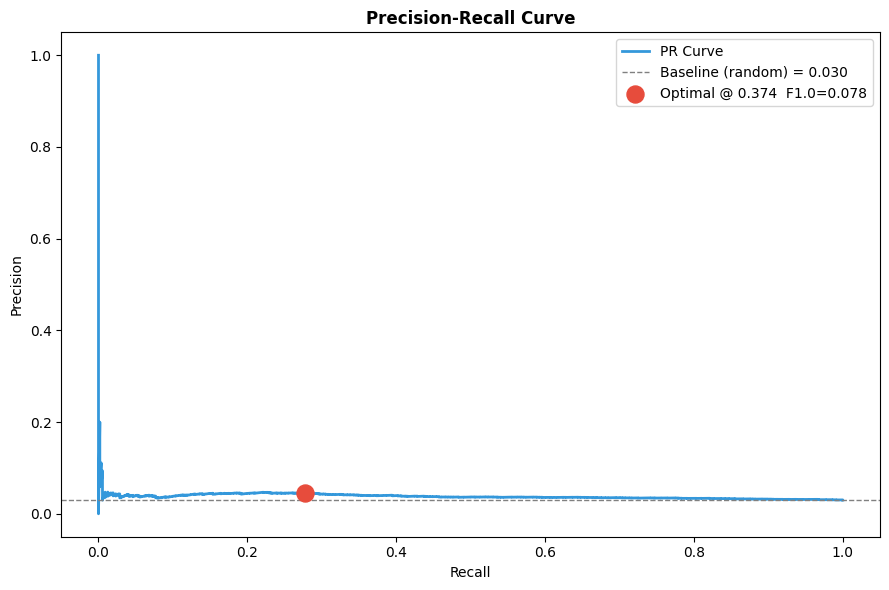


  XGBoost (threshold=0.374)
  AUC-ROC         : 0.5743  ← primary (honest)
  AUC-PR          : 0.0382
  F1 (returners)  : 0.0779  ← minority class

              precision    recall  f1-score   support

    One-time       0.97      0.82      0.89     18110
     Returns       0.05      0.28      0.08       560

    accuracy                           0.80     18670
   macro avg       0.51      0.55      0.48     18670
weighted avg       0.95      0.80      0.87     18670



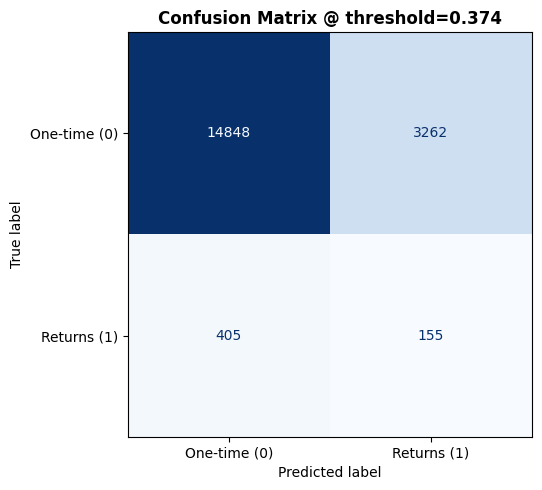


  True Negatives  (correctly predicted one-time) : 14,848
  False Positives (predicted return, actually left): 3,262
  False Negatives (missed actual returners)        : 405
  True Positives  (correctly predicted return)     : 155


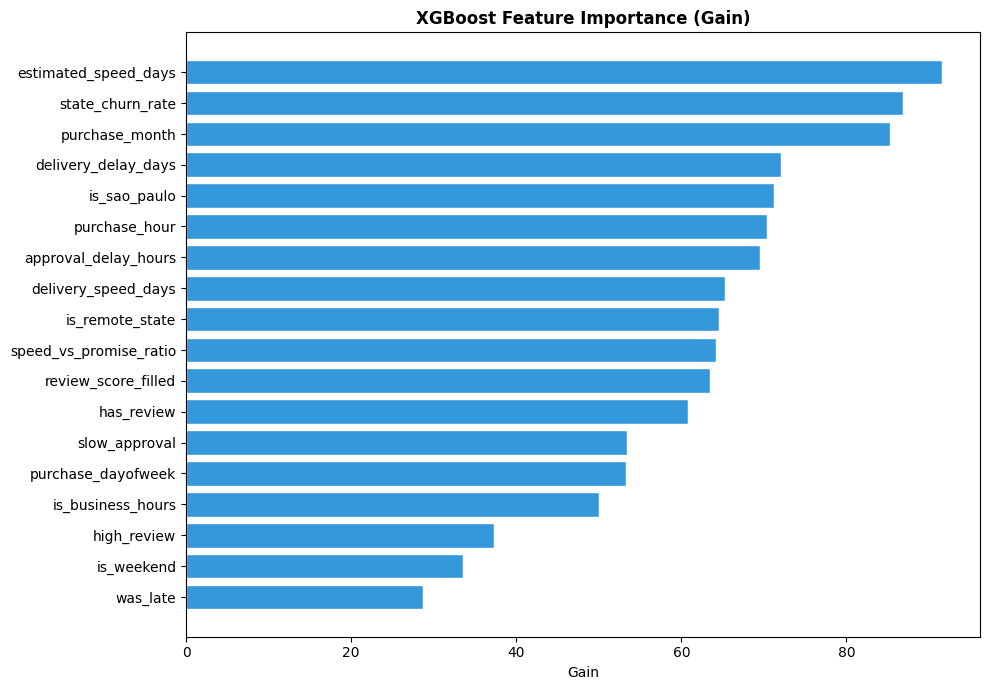

2026-04-24 17:11:26,189 | INFO | Training complete.


In [2]:
# ── Cell 2: Run Full Training Pipeline ────────────────────────────────────────
from importlib import reload
import src.train as tr
reload(tr)
from src.train import run_training

results = run_training(n_optuna_trials=50)

In [3]:
# ── Cell 3: Compare All Models ────────────────────────────────────────────────
import pandas as pd

comparison = pd.DataFrame([
    results['baseline'],
    results['xgb_default'],
    results['xgb_tuned'],
    results['xgb_final'],
])
print(comparison.to_string(index=False))
print(f"\nBest threshold: {results['best_threshold']:.4f}")

                    model  auc_roc   auc_pr   f1_min
            Baseline (LR) 0.534527 0.033144 0.061572
        XGBoost (default) 0.584545 0.039302 0.071684
   XGBoost (Optuna tuned) 0.574290 0.038221 0.003503
XGBoost (threshold=0.374) 0.574290 0.038221 0.077948

Best threshold: 0.3737


In [4]:
# ── Cell: SHAP Analysis ────────────────────────────────────────────────────────
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load model and data
model  = joblib.load('../models/xgb_tuned.pkl')
df     = pd.read_csv('../data/processed/feature_matrix.csv')

FEATURE_COLS = [
    'delivery_delay_days', 'approval_delay_hours',
    'was_late', 'delivery_speed_days', 'estimated_speed_days',
    'speed_vs_promise_ratio', 'has_review', 'review_score_filled',
    'low_review', 'high_review', 'purchase_hour', 'purchase_dayofweek',
    'purchase_month', 'is_weekend', 'is_business_hours',
    'state_churn_rate', 'is_sao_paulo', 'is_remote_state', 'slow_approval'
]

X = df[FEATURE_COLS]
y = df['will_return']

# Sample for speed — SHAP on 93k rows is slow
X_sample = X.sample(n=3000, random_state=42)

# Compute SHAP values
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (3000, 19)


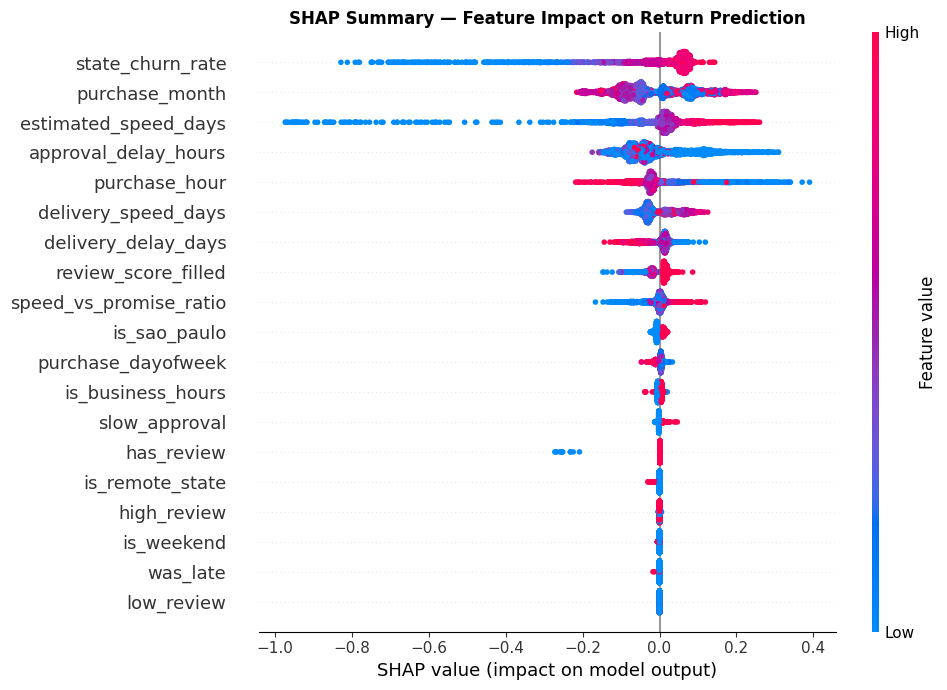

In [5]:
# ── Cell: SHAP Summary Plot ────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP Summary — Feature Impact on Return Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

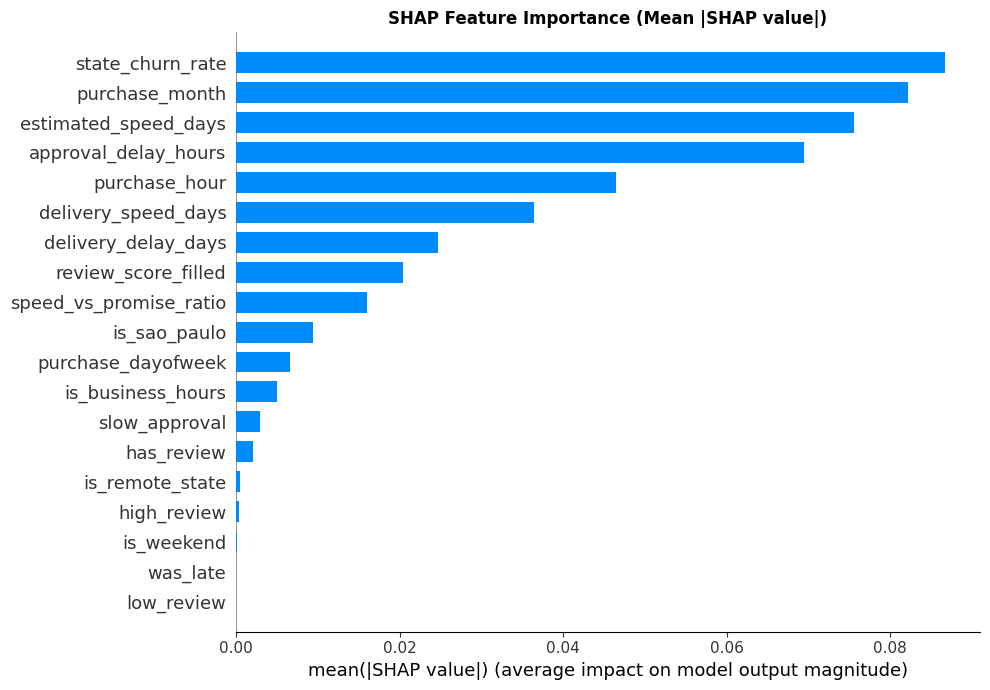

In [6]:
# ── Cell: SHAP Bar Plot (mean absolute impact) ─────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

Top 2 features: ['state_churn_rate', 'purchase_month']


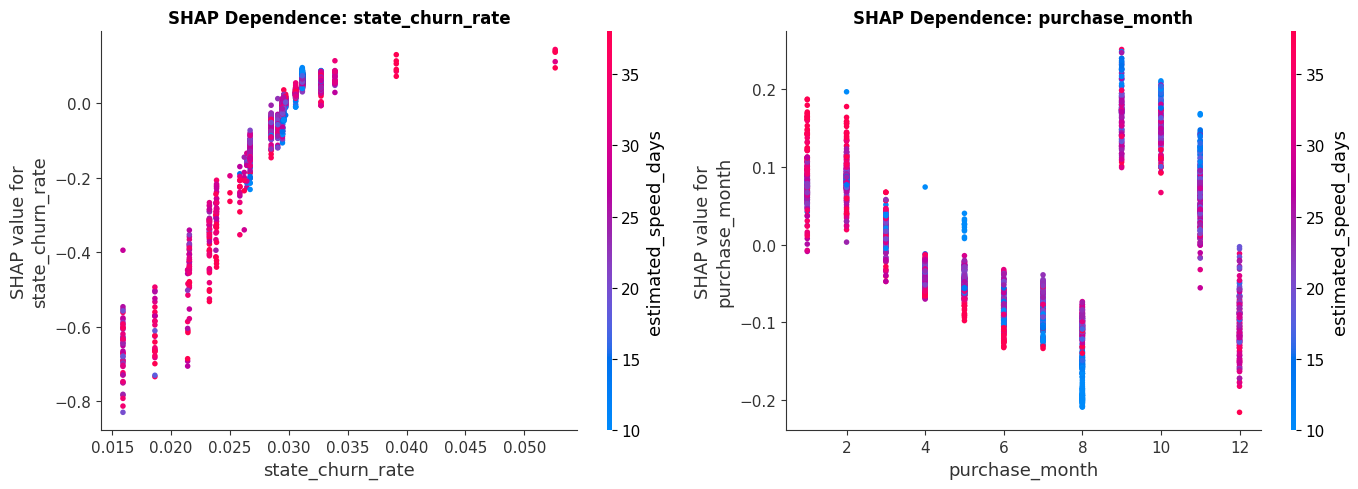

In [9]:
# ── Cell: SHAP Dependence — Top 2 Features ────────────────────────────────────
# Get top 2 features by mean absolute SHAP value
import numpy as np
mean_shap    = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

top2 = mean_shap.index[:2].tolist()
print(f"Top 2 features: {top2}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2):
    shap.dependence_plot(
        feat,
        shap_values,
        X_sample,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

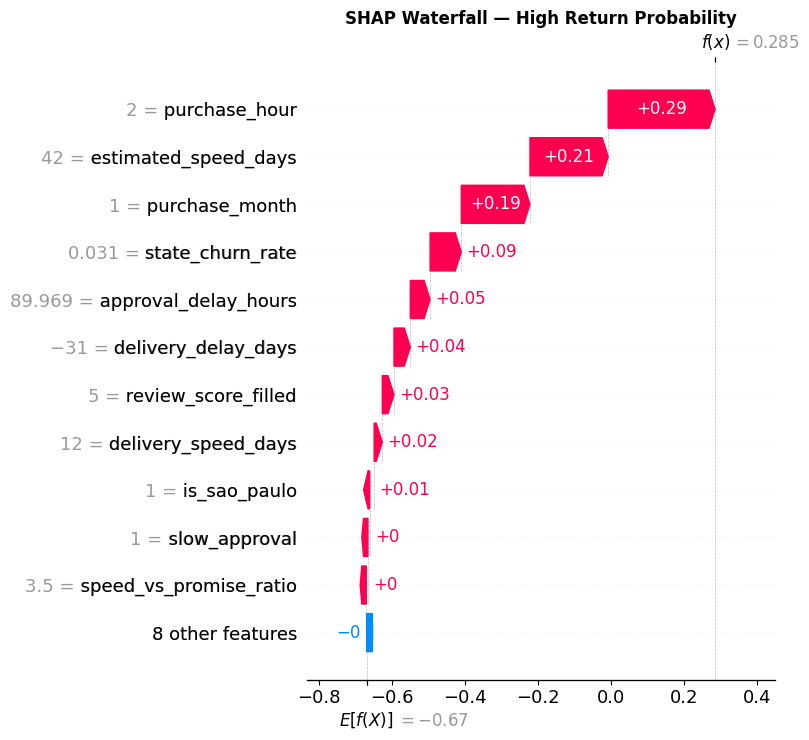


Customer features:
{'state_churn_rate': 0.031146200623435, 'purchase_month': 1.0}
Predicted return probability: 0.5709
Actual label: 0


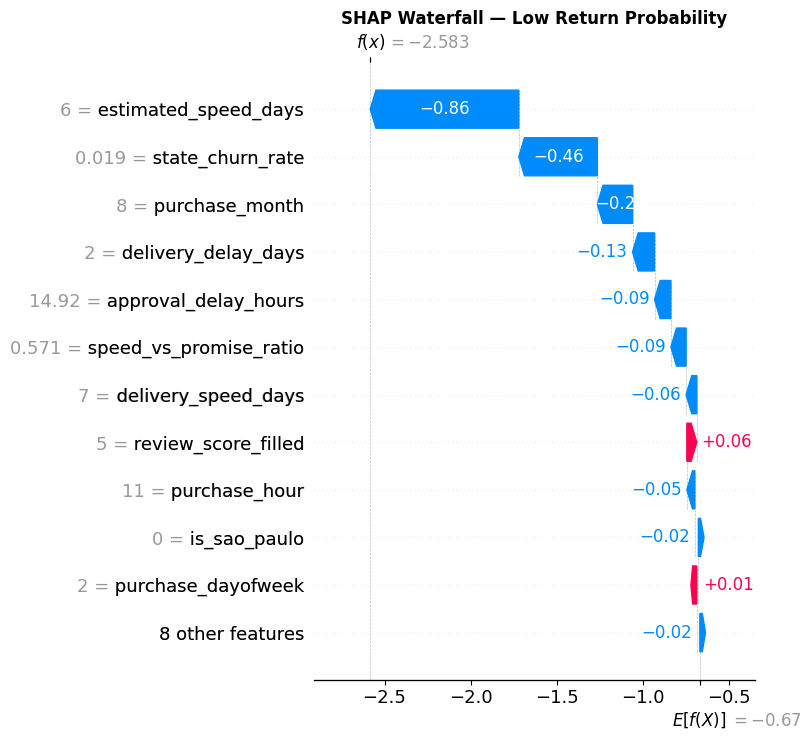


Customer features:
{'state_churn_rate': 0.018624642, 'purchase_month': 8.0}
Predicted return probability: 0.0702
Actual label: 0


In [10]:
# ── Cell: Single Customer Explanation (Waterfall) ──────────────────────────────
# Explain one high-risk and one low-risk prediction

y_prob_all = model.predict_proba(X)[:, 1]

# Find one customer predicted likely to return (high prob)
high_prob_idx = pd.Series(y_prob_all).nlargest(1).index[0]
# Find one customer predicted unlikely to return (low prob)  
low_prob_idx  = pd.Series(y_prob_all).nsmallest(1).index[0]

explainer_v2 = shap.TreeExplainer(model)

for idx, label in [(high_prob_idx, 'High Return Probability'), 
                   (low_prob_idx,  'Low Return Probability')]:
    sv = explainer_v2(X.iloc[[idx]])
    plt.figure()
    shap.waterfall_plot(sv[0], show=False, max_display=12)
    plt.title(f'SHAP Waterfall — {label}', fontweight='bold')
    plt.tight_layout()
    fname = label.lower().replace(' ', '_')
    plt.savefig(f'../data/processed/shap_waterfall_{fname}.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print(f"\nCustomer features:\n{X.iloc[idx][top2].to_dict()}")
    print(f"Predicted return probability: {y_prob_all[idx]:.4f}")
    print(f"Actual label: {y.iloc[idx]}")

In [11]:
# ── Cell: SHAP Summary Table (for README) ─────────────────────────────────────
mean_shap_df = mean_shap.reset_index()
mean_shap_df.columns = ['feature', 'mean_abs_shap']
mean_shap_df['rank'] = range(1, len(mean_shap_df) + 1)

print("Feature importance ranking by SHAP (mean |SHAP value|):")
print(mean_shap_df[['rank', 'feature', 'mean_abs_shap']].to_string(index=False))

Feature importance ranking by SHAP (mean |SHAP value|):
 rank                feature  mean_abs_shap
    1       state_churn_rate       0.086676
    2         purchase_month       0.082147
    3   estimated_speed_days       0.075639
    4   approval_delay_hours       0.069460
    5          purchase_hour       0.046505
    6    delivery_speed_days       0.036401
    7    delivery_delay_days       0.024758
    8    review_score_filled       0.020430
    9 speed_vs_promise_ratio       0.015969
   10           is_sao_paulo       0.009446
   11     purchase_dayofweek       0.006568
   12      is_business_hours       0.005005
   13          slow_approval       0.002921
   14             has_review       0.002073
   15        is_remote_state       0.000474
   16            high_review       0.000296
   17             is_weekend       0.000130
   18               was_late       0.000040
   19             low_review       0.000000
